device → cuda


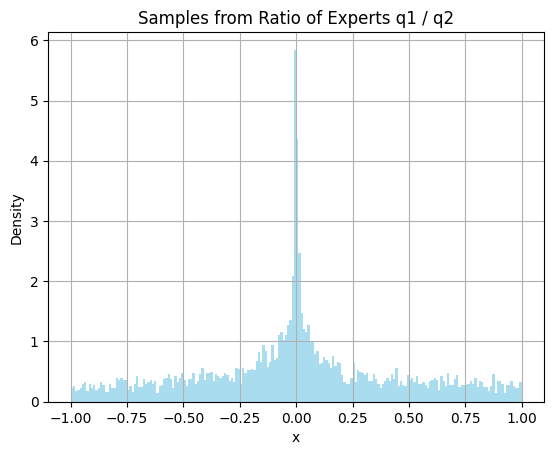

In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import random, os
from datetime import datetime
import os
import torch
import numpy as np
import pandas as pd
from utils.metrics.export import compute_sample_based_metrics_1d
from hcg.interpolant import MLPInstFlexible, run_training_v_s
from hcg.sample_data import sample_checkerboard, make_conditions, sample_data_model1, sample_data_model2, sample_data_model3, ground_truth_hcg, plot_diagnostics
from hcg.hcg import simulate_hcg, simulate_hcg_generalized

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0); random.seed(0); np.random.seed(0)
print("device →", device)

### Run this ONCE per experiment
new_experiment = True  # Set to False to reuse an old experiment ID
if new_experiment:  # Run the experiment with the current date and time as the experiment ID
    experiment_id = f"experiment_pathological_{datetime.now().strftime('%Y%m%d')}" #_%H%M%S
    os.makedirs(experiment_id, exist_ok=True)
else:
    experiment_id = "experiment_pathological_250904"  # Use a fixed ID for reproducibility

bs = 5000

def sample_pathological_example(bs):
    """
    Sample from density f(x) ∝ |x|^{-1/2} on (-1,1).
    
    Args:
        bs (int): batch size
    
    Returns:
        torch.Tensor: samples of shape (bs,)
    """
    # uniform(0,1)
    u = torch.rand(bs, device=device)
    # inverse CDF: x = u^2 on [0,1]
    x = u**2
    # randomly assign sign
    signs = torch.where(torch.rand(bs) < 0.5, -1.0, 1.0).to(device)
    return (signs * x).reshape(-1,1), None

def sample_tmp(bs, id=0):
    """
    Samples from q^1(x): N(-2, 0.5^2)
    `cond` is a dummy argument for compatibility (e.g., A)
    """
    return torch.randn(bs, 1, device=device) + (-2.0), None
    
# Example usage:
samples_gt, _ = sample_pathological_example(bs)
samples_gt = samples_gt.cpu().numpy()
plt.hist(samples_gt, bins=200, density=True, alpha=0.7, color="skyblue")
plt.title("Samples from Ratio of Experts q1 / q2")
plt.grid(True)
plt.xlabel("x")#; plt.xlim(-5,5)
plt.ylabel("Density")
plt.show()

In [2]:
if False:
    # Training takes ~2min on a single GPU
    u_q1 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device) # X | A
    s_q1 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device) # X | A
    run_training_v_s(u_q1, s_q1, sample_pathological_example, plot_cond_val=None, n_iters=10000)
    # save the models
    torch.save(u_q1.state_dict(), f"{experiment_id}/path_u_q1.pth")
    torch.save(s_q1.state_dict(), f"{experiment_id}/path_s_q1.pth")

# With Pretrained Models

In [2]:
# Load all the models
u_q1 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device)
s_q1 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device)
u_q1.load_state_dict(torch.load(f"{experiment_id}/path_u_q1.pth"))
s_q1.load_state_dict(torch.load(f"{experiment_id}/path_s_q1.pth"))

# v1: for q^1 (N(-2))
def v1_fn(x, t): return u_q1(x, t)
def s1_fn(x, t): return s_q1(x, t) - x
def sigma_fn(t): return 1.0 * torch.ones_like(t)
print("Models loaded.")

Models loaded.


/tmp/ipykernel_2136656/1088378464.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  u_q1.load_state_dict(torch.load(f"{experiment_id}/path_u_q1.pth"))
/tmp/ipykernel_21366

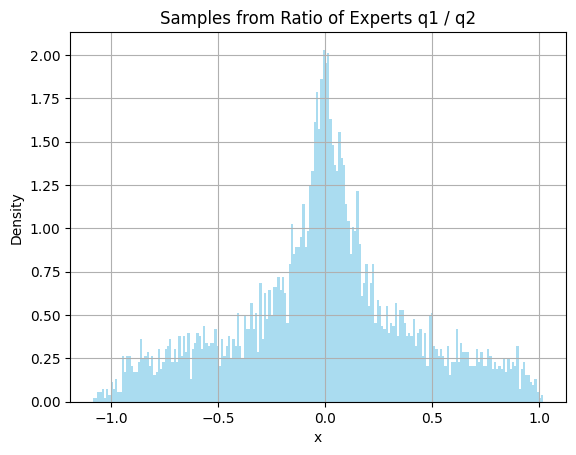

[[0.026335289879447103, 0.03382728147978583, 0.02602529525756836]]


In [3]:
gamma = 1 # Compare 1 vs 30
x0 = (1/torch.sqrt(torch.tensor(gamma))) * torch.randn(bs, 1).to("cuda")  # (X, Y) sample

samples, logw_final, logw_history, sample_history = simulate_hcg_generalized(
    x0=x0, 
    dim_list=[1], 
    v_fn_list=[
        lambda x, t: v1_fn(x, t),                                                 # v1(X)
    ],
    s_fn_list=[
        lambda x, t: s1_fn(x, t),                                                 # s1(X)
    ],
    gamma_list=[gamma],     # from log-weight increment in simulate_hcg
    proj_list=[
        lambda z: z, 
    ],
    emb_list=[
        lambda z: z,  # identity
    ],
    sigma_fn=sigma_fn,
    v_star= lambda z, t: v1_fn(z, t), 
    t0=0.0, t1=1.0, n_steps=1000,
    device="cuda",
    resample=True,
    ess_threshold=0.5
)
samples = samples.cpu().numpy()
plt.hist(samples, bins=200, density=True, alpha=0.7, color="skyblue")
plt.title("Samples from Ratio of Experts q1 / q2")
plt.grid(True)
plt.xlabel("x")#plt.xlim(-5,5)
plt.ylabel("Density")
plt.show()

results = []
samples_gt, _ = sample_pathological_example(bs)
samples_gt = samples_gt.cpu().numpy()
w1, w2, mmd_rbf = compute_sample_based_metrics_1d(
    torch.tensor(samples_gt), torch.tensor(samples)
)
results.append([w1, w2, mmd_rbf])
print(results)

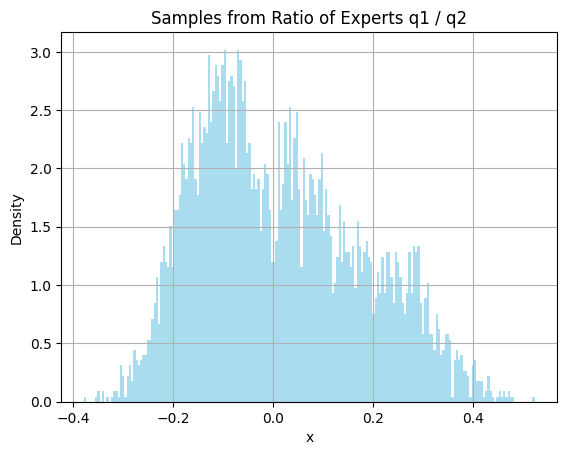

[[0.19965231022889293, 0.2851345842474591, 0.6401472091674805]]


In [4]:
gamma = 30 # Compare 1 vs 30
x0 = (1/torch.sqrt(torch.tensor(gamma))) * torch.randn(bs, 1).to("cuda")  # (X, Y) sample

samples, logw_final, logw_history, sample_history = simulate_hcg_generalized(
    x0=x0, 
    dim_list=[1], 
    v_fn_list=[
        lambda x, t: v1_fn(x, t),                                                 # v1(X)
    ],
    s_fn_list=[
        lambda x, t: s1_fn(x, t),                                                 # s1(X)
    ],
    gamma_list=[gamma],     # from log-weight increment in simulate_hcg
    proj_list=[
        lambda z: z, 
    ],
    emb_list=[
        lambda z: z,  # identity
    ],
    sigma_fn=sigma_fn,
    v_star= lambda z, t: v1_fn(z, t), 
    t0=0.0, t1=1.0, n_steps=1000,
    device="cuda",
    resample=True,
    ess_threshold=0.5
)
samples = samples.cpu().numpy()
plt.hist(samples, bins=200, density=True, alpha=0.7, color="skyblue")
plt.title("Samples from Ratio of Experts q1 / q2")
plt.grid(True)
plt.xlabel("x")#plt.xlim(-5,5)
plt.ylabel("Density")
plt.show()

results = []
samples_gt, _ = sample_pathological_example(bs)
samples_gt = samples_gt.cpu().numpy()
w1, w2, mmd_rbf = compute_sample_based_metrics_1d(
    torch.tensor(samples_gt), torch.tensor(samples)
)
results.append([w1, w2, mmd_rbf])
print(results)